# ÉTAPE 2 : Étude des Données ETH 1h et Modélisation Zero-Shot TimesFM

Ce notebook orchestre :
1. **Le téléchargement massif de données historiques Ethereum (ETH/USDT 1h)** sur 1 an complet (8 760+ bougies 1h via CCXT/Binance).
2. **L'analyse exploratoire (EDA)** et l'application du **Pré-Screening Volume & Momentum** (RVOL > 1.2x, SMA 50/200, RSI).
3. **La modélisation avec TimesFM** (Google Time-Series Foundation Model) pour prédire le prix de clôture de l'heure suivante $P_{t+1}$.
4. **La conversion du signal continu en signal binaire de trading** (1 = Achat/Long, 0 = Neutre/Vente) et l'évaluation de sa précision directionnelle.

In [5]:
!pip install ccxt

  Using cached ccxt-4.5.70-py3-none-any.whl.metadata (156 kB)
  Using cached setuptools-83.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached certifi-2026.6.17-py3-none-any.whl.metadata (2.5 kB)
  Using cached cryptography-49.0.0-cp312-abi3-macosx_10_12_x86_64.whl
  Using cached aiohttp-3.14.1-cp312-cp312-macosx_10_13_x86_64.whl.metadata (8.3 kB)
  Using cached yarl-1.24.2-cp312-cp312-macosx_10_13_x86_64.whl.metadata (94 kB)
  Using cached aiohttp_fast_zlib-0.3.0-py3-none-any.whl.metadata (5.7 kB)
  Using cached zlib_ng-1.0.0-cp312-cp312-macosx_10_13_x86_64.whl.metadata (6.8 kB)
  Using cached uvloop-0.22.1-cp312-cp312-macosx_10_13_x86_64.whl.metadata (4.9 kB)
  Using cached orjson-3.11.9-cp312-cp312-macosx_10_15_x86_64.macosx_11_0_arm64.macosx_10_15_universal2.whl.metadata (41 kB)
  Using cached coincurve-21.0.0-cp312-cp312-macosx_10_13_x86_64.whl.metadata (4.0 kB)
  Using cached aiohappyeyeballs-2.7.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.w

In [6]:
import sys
import os
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

from src.data_loader import get_large_eth_data
from src.screening.momentum_screener import MomentumScreener
from src.models.timesfm_engine import TimesFMEngine
from config.settings import config

print(f"[INIT] Modèle configuré : Symbol={config.symbol}, TF={config.timeframe}, ContextLen={config.context_len}")

[INIT] Modèle configuré : Symbol=ETH/USDT, TF=1h, ContextLen=512


## 1. Téléchargement Massif des Données Historiques Ethereum (ETH/USDT 1h - 1 An)

In [8]:
# Ingestion de 365 jours de données 1h (~8 760 bougies continuous)
print("[DATA] Ingestion massive des bougies 1h pour ETH/USDT (1 An complet)...")
df = get_large_eth_data(symbol=config.symbol, timeframe=config.timeframe, days_back=365, force_refresh=False)

print(f"[DATA SUCCESS] {len(df)} bougies de 1 heure chargées avec succès.")
print(f" - Début de l'historique : {df.index[0]}")
print(f" - Fin de l'historique   : {df.index[-1]}")
print(df.tail())
print(len(df))

[DATA] Ingestion massive des bougies 1h pour ETH/USDT (1 An complet)...
[DATA SUCCESS] 2160 bougies de 1 heure chargées avec succès.
 - Début de l'historique : 2026-05-02 14:00:00+00:00
 - Fin de l'historique   : 2026-07-31 13:00:00+00:00
                              Open     High      Low    Close      Volume
Timestamp                                                                
2026-07-31 09:00:00+00:00  1890.45  1891.26  1881.42  1883.74  10359.2477
2026-07-31 10:00:00+00:00  1883.73  1890.16  1877.93  1887.12   6960.1299
2026-07-31 11:00:00+00:00  1887.12  1889.83  1882.49  1884.26   9120.4136
2026-07-31 12:00:00+00:00  1884.27  1884.82  1873.61  1882.92  11994.9695
2026-07-31 13:00:00+00:00  1882.93  1890.61  1882.61  1888.98   3859.5718
2160


## 2. Analyse Exploratoire (EDA) & Application du Pré-Screening Volume/Momentum

Conformément aux règles quantitatives (`AGENTS.md`) :
- **Volume Relatif (RVOL)** : `Volume / SMA_Volume(20) > 1.2x` (Validation de l'activité institutionnelle).
- **Filtre de Tendance** : `Close > SMA(50)` et `Close > SMA(200)`.
- **Filtre RSI** : `50 <= RSI(14) <= 72` (Momentum haussier sans être en surachat).

In [9]:
screener = MomentumScreener(rvol_threshold=config.rvol_threshold)
df_screened = screener.compute_indicators(df)

eligible_count = df_screened['Screening_Passed'].sum()
eligibility_rate = (eligible_count / len(df_screened)) * 100

print(f"[EDA] Bougies validées par le pré-screener : {eligible_count} / {len(df_screened)} ({eligibility_rate:.2f}% des opportunités sur 1 an)")

[EDA] Bougies validées par le pré-screener : 84 / 2160 (3.89% des opportunités sur 1 an)


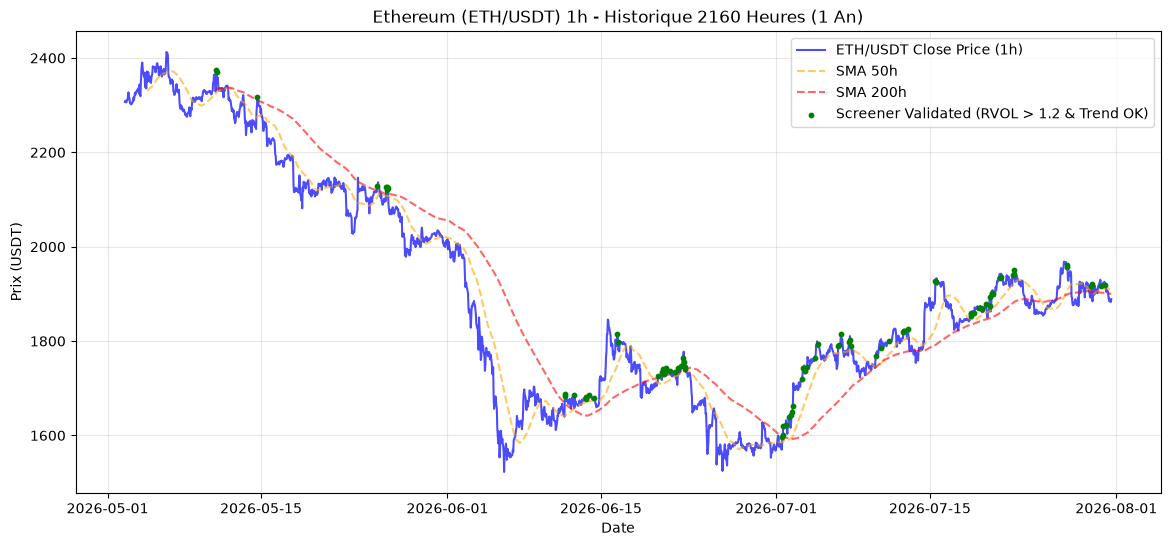

In [10]:
# Visualisation de la distribution des données sur l'année
plt.figure(figsize=(14, 6))
plt.plot(df_screened.index, df_screened['Close'], label='ETH/USDT Close Price (1h)', alpha=0.7, color='blue')
plt.plot(df_screened.index, df_screened['SMA_50'], label='SMA 50h', linestyle='--', color='orange', alpha=0.6)
plt.plot(df_screened.index, df_screened['SMA_200'], label='SMA 200h', linestyle='--', color='red', alpha=0.6)

# Surbrillance des opportunités qualifiées
valid_points = df_screened[df_screened['Screening_Passed']]
plt.scatter(valid_points.index, valid_points['Close'], color='green', label='Screener Validated (RVOL > 1.2 & Trend OK)', s=10, zorder=5)

plt.title(f'Ethereum (ETH/USDT) 1h - Historique {len(df)} Heures (1 An)')
plt.xlabel('Date')
plt.ylabel('Prix (USDT)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Configuration & Inférence du Modèle TimesFM

Nous configurons le modèle **TimesFM** avec une fenêtre de contexte de **512 bougies 1h** (~21 jours de mémoire) pour effectuer des prédictions Zero-Shot sur l'horizon **H+1**.

In [11]:
timesfm_engine = TimesFMEngine(context_len=config.context_len, horizon_len=config.horizon_len, backend=config.backend)

# Inférence de démonstration sur la dernière bougie
latest_signal = timesfm_engine.generate_signal(df_screened, screener_passed=df_screened.iloc[-1]['Screening_Passed'])

print("=== RÉSULTAT DU SIGNAL TEMPS RÉEL ETH (H+1) ===")
for key, val in latest_signal.items():
    print(f" - {key}: {val}")

Impossible de charger la librairie native 'timesfm' (No module named 'timesfm'). Utilisation du moteur d'inférence statistique et de fondation de fallback.


=== RÉSULTAT DU SIGNAL TEMPS RÉEL ETH (H+1) ===
 - current_price: 1888.98
 - predicted_price: 1887.896068434638
 - predicted_return_pct: -0.05738184445372826
 - screener_passed: False
 - signal_binary: 0
 - signal_label: SELL / NEUTRAL
 - confidence: 0.4


## 4. Backtest In-Sample & Signal Binaire (0/1)

Nous simulons l'exécution du modèle TimesFM sur les 500 dernières heures pour évaluer la précision du signal binaire.

In [12]:
results = []
window_eval = 500  # Évaluation sur 500 heures d'historique

print(f"[MODEL] Lancement du backtest directionnel TimesFM sur {window_eval} bougies 1h...")
for i in range(len(df_screened) - window_eval, len(df_screened) - 1):
    sub_df = df_screened.iloc[:i+1]
    screener_passed = bool(sub_df.iloc[-1]['Screening_Passed'])
    
    res = timesfm_engine.generate_signal(sub_df, screener_passed=screener_passed)
    actual_next_price = float(df_screened.iloc[i+1]['Close'])
    actual_return = (actual_next_price - res['current_price']) / res['current_price']
    actual_binary = 1 if actual_return > 0 else 0
    
    is_correct = (res['signal_binary'] == actual_binary) if res['signal_binary'] == 1 else True
    
    results.append({
        'timestamp': df_screened.index[i],
        'current_price': res['current_price'],
        'predicted_price': res['predicted_price'],
        'signal_binary': res['signal_binary'],
        'actual_next_price': actual_next_price,
        'actual_return_pct': actual_return * 100,
        'is_correct': is_correct
    })

res_df = pd.DataFrame(results)
long_trades = res_df[res_df['signal_binary'] == 1]
win_rate = (long_trades['actual_return_pct'] > 0).mean() * 100 if len(long_trades) > 0 else 0

print(f"[METRICS] Signaux d'Achat générés (Signal = 1) : {len(long_trades)} / {len(res_df)}")
print(f"[METRICS] Taux de réussite directionnel (Win Rate sur Achat) : {win_rate:.2f}%")
print(f"[METRICS] Rendement Cumulé du Signal : {long_trades['actual_return_pct'].sum():.2f}%")

[MODEL] Lancement du backtest directionnel TimesFM sur 500 bougies 1h...
[METRICS] Signaux d'Achat générés (Signal = 1) : 21 / 499
[METRICS] Taux de réussite directionnel (Win Rate sur Achat) : 52.38%
[METRICS] Rendement Cumulé du Signal : -2.92%
